<a href="https://colab.research.google.com/github/IT24100378/ToxicCommentNLPfinal/blob/Remove-Stopwards/Remove_Stopwords.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already
nltk.download('stopwords')

# ---------------- Step 1: Load Dataset ----------------
import csv
df = pd.read_csv("/content/train_tokenized.csv", on_bad_lines='skip', engine='python')



# Show dataset info and first 5 rows
print("\nDataset Info:")
print(df.info())
print("\nFirst 5 Rows:")
print(df.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152289 entries, 0 to 152288
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   id      152289 non-null  object
 1   tokens  152289 non-null  object
 2   toxic   152289 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 3.5+ MB
None

First 5 Rows:
                 id                                             tokens  toxic
0  0000997932d777bf  ['explanation', 'why', 'the', 'edits', 'made',...      0
1  000103f0d9cfb60f  ['daww', 'he', 'matches', 'this', 'background'...      0
2  000113f07ec002fd  ['hey', 'man', 'im', 'really', 'not', 'trying'...      0
3  0001b41b1c6bb37e  ['more', 'i', 'cant', 'make', 'any', 'real', '...      0
4  0001d958c54c6e35  ['you', 'sir', 'are', 'my', 'hero', 'any', 'ch...      0


Shape of dataset: (152289, 4)

First 5 rows:
                  id                                             tokens  toxic  \
0  0000997932d777bf  ['explanation', 'why', 'the', 'edits', 'made',...      0   
1  000103f0d9cfb60f  ['daww', 'he', 'matches', 'this', 'background'...      0   
2  000113f07ec002fd  ['hey', 'man', 'im', 'really', 'not', 'trying'...      0   
3  0001b41b1c6bb37e  ['more', 'i', 'cant', 'make', 'any', 'real', '...      0   
4  0001d958c54c6e35  ['you', 'sir', 'are', 'my', 'hero', 'any', 'ch...      0   

   word_count  
0          43  
1          17  
2          42  
3         109  
4          13  

Missing values:
 id            0
tokens        0
toxic         0
word_count    0
dtype: int64

Class distribution:
 toxic
0    137710
1     14579
Name: count, dtype: int64


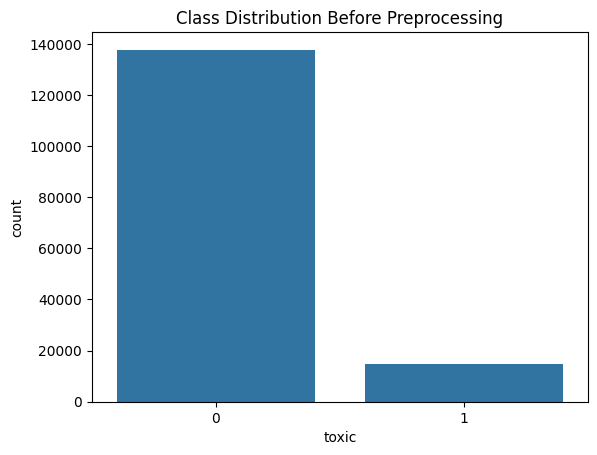

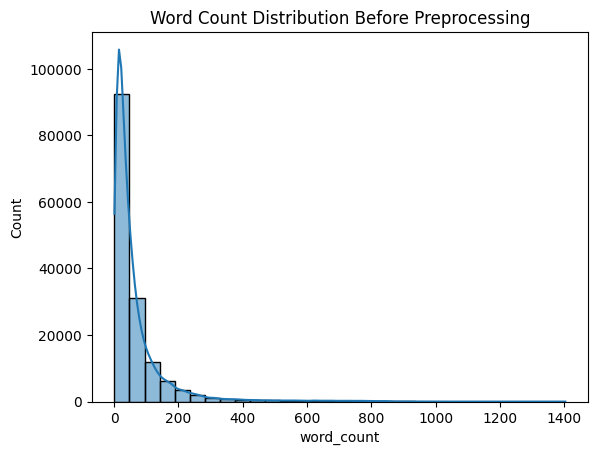

In [4]:
# ---------------- Step 2: EDA Before Preprocessing ----------------
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution:\n", df['toxic'].value_counts())

# Plot toxic distribution
sns.countplot(x='toxic', data=df)
plt.title("Class Distribution Before Preprocessing")
plt.show()

# Word count before preprocessing
df['word_count'] = df['tokens'].apply(lambda x: len(str(x).split()))
sns.histplot(df['word_count'], bins=30, kde=True)
plt.title("Word Count Distribution Before Preprocessing")
plt.show()





In [5]:
# ---------------- Step 3: Stopword Removal ----------------
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = str(text).split()
    filtered_words = [w for w in words if w.lower() not in stop_words]
    return " ".join(filtered_words)

df['tokens'] = df['tokens'].apply(remove_stopwords)


After preprocessing (stopword removal):
                 id                                             tokens  toxic
0  0000997932d777bf  ['explanation', 'why', 'the', 'edits', 'made',...      0
1  000103f0d9cfb60f  ['daww', 'he', 'matches', 'this', 'background'...      0
2  000113f07ec002fd  ['hey', 'man', 'im', 'really', 'not', 'trying'...      0
3  0001b41b1c6bb37e  ['more', 'i', 'cant', 'make', 'any', 'real', '...      0
4  0001d958c54c6e35  ['you', 'sir', 'are', 'my', 'hero', 'any', 'ch...      0


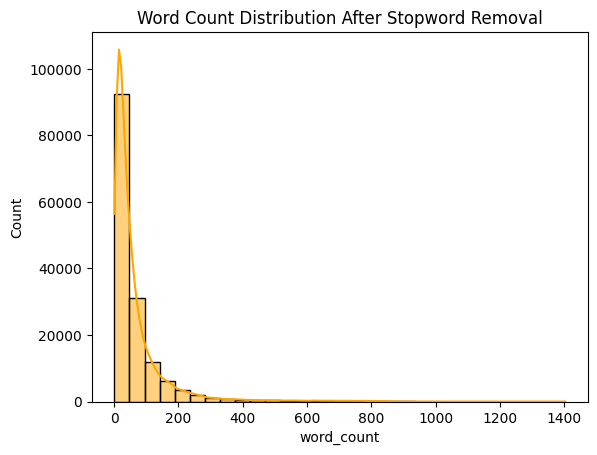

In [6]:
# ---------------- Step 4: EDA After Preprocessing ----------------
print("\nAfter preprocessing (stopword removal):")
df['word_count'] = df['tokens'].apply(lambda x: len(str(x).split()))
print(df[['id', 'tokens', 'toxic']].head())

# Plot word count after preprocessing
sns.histplot(df['word_count'], bins=30, kde=True, color="orange")
plt.title("Word Count Distribution After Stopword Removal")
plt.show()

In [7]:
# ---------------- Step 5: Save Final Preprocessed File ----------------
final_df = df[['id', 'tokens', 'toxic']]
final_df.to_csv("preprocessed_stopwords_removed.csv", index=False)

print("✅ Preprocessed file saved as 'preprocessed_stopwords_removed.csv'")

✅ Preprocessed file saved as 'preprocessed_stopwords_removed.csv'
